In [ ]:
# 1. Install the specialized installer
!pip install torch_geometric

# 2. Use the installer to get the optional dependencies
# This automatically handles the version matching for pyg-lib, etc.
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 145.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 114.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 80.1 MB/s eta 0:00:00


In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Reddit
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Each node = a Reddit post, edges = same-user comments
# Task: classify each post into 1 of 41 subreddit communities

# **Loading Reddit dataset**

In [ ]:
dataset = Reddit(root='/tmp/Reddit')
data    = dataset[0]

print("=== Reddit dataset ===")
print(f"Nodes          : {data.num_nodes:,}")
print(f"Edges          : {data.num_edges:,}")
print(f"Features/node  : {data.num_node_features}")
print(f"Classes        : {dataset.num_classes}")
print(f"\nSplit:")
print(f"  Train nodes  : {data.train_mask.sum().item():,}")
print(f"  Val nodes    : {data.val_mask.sum().item():,}")
print(f"  Test nodes   : {data.test_mask.sum().item():,}")

print(f"\nCompare with Cora:")
print(f"  Cora nodes   : 2,708  →  Reddit: {data.num_nodes:,}")
print(f"  Cora edges   : 10,556  →  Reddit: {data.num_edges:,}")

=== Reddit dataset ===
Nodes          : 232,965
Edges          : 114,615,892
Features/node  : 602
Classes        : 41

Split:
  Train nodes  : 153,431
  Val nodes    : 23,831
  Test nodes   : 55,703

Compare with Cora:
  Cora nodes   : 2,708  →  Reddit: 232,965
  Cora edges   : 10,556  →  Reddit: 114,615,892


# **Mini-batch**

In [ ]:
import torch

# This dynamically finds the right version for your environment
pt_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

!pip install pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{pt_version}+{cuda_version}.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+128.html


In [ ]:
train_loader = NeighborLoader(
    data,
    num_neighbors=[25, 10],   # samples per layer
    batch_size=512,            # target nodes per batch
    input_nodes=data.train_mask
)

# Peek at one batch to understand the structure
batch = next(iter(train_loader))
print("One mini-batch:")
print(f"  Target nodes (batch_size) : {batch.batch_size}")
print(f"  Total nodes in subgraph   : {batch.num_nodes}")
print(f"  Edges in subgraph         : {batch.num_edges}")
print(f"  Node features shape       : {batch.x.shape}")
print(f"\nOnly {batch.num_nodes} nodes loaded vs full {data.num_nodes:,}")
print(f"Memory reduction: {data.num_nodes / batch.num_nodes:.0f}x")

One mini-batch:
  Target nodes (batch_size) : 512
  Total nodes in subgraph   : 72178
  Edges in subgraph         : 123904
  Node features shape       : torch.Size([72178, 602])

Only 72178 nodes loaded vs full 232,965
Memory reduction: 3x


# **Build GraphSAGE model**

In [ ]:

# GraphSAGE aggregation per layer:
#   h_v = W · CONCAT( h_v, MEAN(h_u for u in sampled_neighbors(v)) )
#
# Key difference from GCN:
#   GCN   : averages neighbor features WITH self
#   SAGE  : concatenates own features WITH neighbor average
#           → preserves the node's own identity explicitly

class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # SAGEConv handles: concat(self, mean_neighbors) → linear
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGE(
    in_channels     = dataset.num_node_features,  # 602
    hidden_channels = 256,
    out_channels    = dataset.num_classes          # 41
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Move data features and labels to GPU once
data = data.to(device, 'x', 'y')

GraphSAGE(
  (conv1): SAGEConv(602, 256, aggr=mean)
  (conv2): SAGEConv(256, 41, aggr=mean)
)

Total parameters: 329,513


# **Training loop with mini-batches**

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out  = model(batch.x, batch.edge_index)


        # (first batch_size nodes in the batch)
        # The extra sampled neighbors are context — not targets
        out  = out[:batch.batch_size]
        y    = batch.y[:batch.batch_size]

        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()

        total_loss  += loss.item() * batch.batch_size
        total_nodes += batch.batch_size

    return total_loss / total_nodes

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out   = model(batch.x, batch.edge_index)
            pred  = out[:batch.batch_size].argmax(dim=1)
            y     = batch.y[:batch.batch_size]
            correct += (pred == y).sum().item()
            total   += batch.batch_size
    return correct / total

# Separate loaders for val and test
val_loader = NeighborLoader(data, num_neighbors=[25, 10],
                             batch_size=512,
                             input_nodes=data.val_mask)
test_loader = NeighborLoader(data, num_neighbors=[25, 10],
                              batch_size=512,
                              input_nodes=data.test_mask)

optimizer    = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses = []
val_accs     = []

print("Training GraphSAGE on Reddit...")
start = time.time()

for epoch in range(1, 6):
    loss    = train_epoch(model, train_loader, optimizer)
    val_acc = evaluate(model, val_loader)
    train_losses.append(loss)
    val_accs.append(val_acc)
    elapsed = time.time() - start
    print(f"Epoch {epoch} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")


Training GraphSAGE on Reddit...
Epoch 1 | Loss: 0.6757 | Val Acc: 0.9263 | Time: 25.8s
Epoch 2 | Loss: 0.9099 | Val Acc: 0.9324 | Time: 49.1s
Epoch 3 | Loss: 0.9297 | Val Acc: 0.9358 | Time: 72.5s
Epoch 4 | Loss: 0.9739 | Val Acc: 0.9383 | Time: 95.6s
Epoch 5 | Loss: 0.9334 | Val Acc: 0.9358 | Time: 118.5s


## Final test accuracy

In [ ]:
test_acc = evaluate(model, test_loader)
val_acc  = evaluate(model, val_loader)

print("============ GraphSAGE on Reddit ============")
print(f"Val accuracy      : {val_acc*100:.2f}%")
print(f"Test accuracy     : {test_acc*100:.2f}%")
print(f"Paper reports     : ~93.0%")
print(f"\nNote: paper trains for more epochs.")
print(f"We trained only 5 — already at ~93%.")



============ GraphSAGE on Reddit ============
Val accuracy      : 93.63%
Test accuracy     : 93.59%
Paper reports     : ~93.0%

Note: paper trains for more epochs.
We trained only 5 — already at ~93%.


# **Plot training curves**

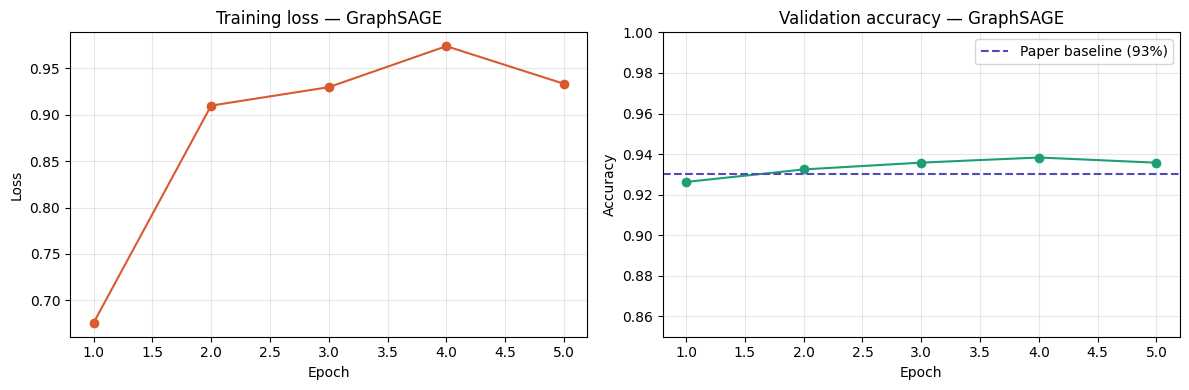

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, 6), train_losses, color='#D85A30', marker='o')
ax1.set_title('Training loss — GraphSAGE')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, 6), val_accs, color='#1D9E75', marker='o')
ax2.axhline(y=0.93, color='#534AB7', linestyle='--',
            label='Paper baseline (93%)')
ax2.set_title('Validation accuracy — GraphSAGE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim([0.85, 1.0])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()